<a href="https://colab.research.google.com/github/2403a51016/AIAC_16/blob/main/task3_week12_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Random Path Distance: 955.03


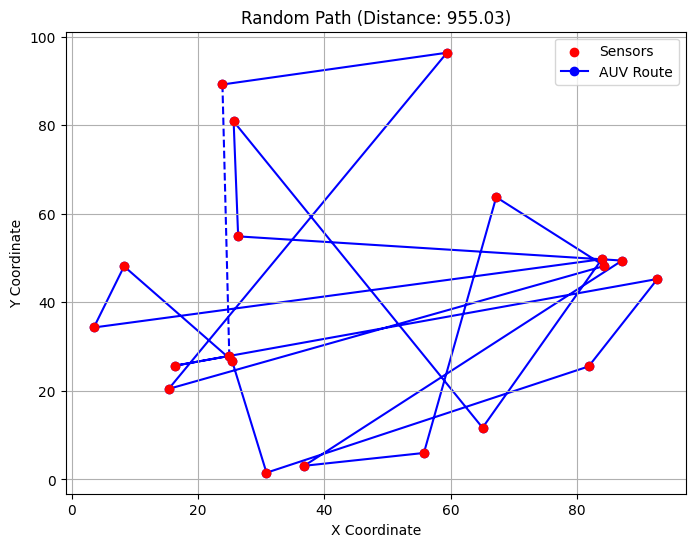

Greedy Path Distance: 311.75


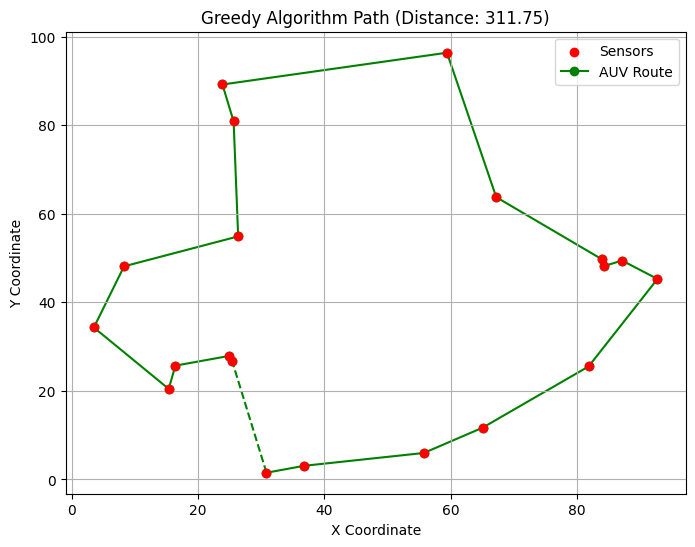

Genetic Algorithm Path Distance: 311.75


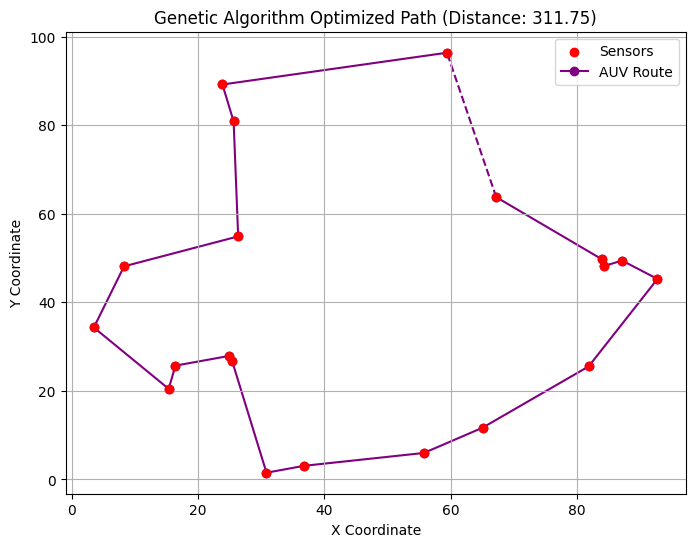


--- Route Optimization Summary ---
Random Path Improvement: 67.36%
Greedy Path Improvement: 0.00%


In [1]:
import math
import random
import matplotlib.pyplot as plt

# --- 1. Data Generation and Helper Functions ---
def generate_sensor_coordinates(num_sensors):
    """Generates random (x, y) coordinates for sensors."""
    return [(random.uniform(0, 100), random.uniform(0, 100)) for _ in range(num_sensors)]

def euclidean_distance(p1, p2):
    """Calculates the Euclidean distance between two points (x, y)."""
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

def calculate_total_distance(route, coordinates):
    """Calculates the total distance of a given route."""
    distance = 0
    if len(route) < 2:
        return 0

    for i in range(len(route) - 1):
        p1 = coordinates[route[i]]
        p2 = coordinates[route[i+1]]
        distance += euclidean_distance(p1, p2)

    start_point = coordinates[route[0]]
    end_point = coordinates[route[-1]]
    distance += euclidean_distance(end_point, start_point)

    return distance

def plot_route(coordinates, route, title, color='blue'):
    """Visualizes the AUV route."""
    plt.figure(figsize=(8, 6))
    x_coords = [p[0] for p in coordinates]
    y_coords = [p[1] for p in coordinates]
    plt.scatter(x_coords, y_coords, c='red', label='Sensors', zorder=2)

    route_x = [coordinates[i][0] for i in route]
    route_y = [coordinates[i][1] for i in route]
    plt.plot(route_x, route_y, c=color, linestyle='-', marker='o', label='AUV Route', zorder=1)

    start_x, start_y = coordinates[route[0]]
    end_x, end_y = coordinates[route[-1]]
    plt.plot([end_x, start_x], [end_y, start_y], c=color, linestyle='--', zorder=1)

    plt.title(title)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.legend()
    plt.grid(True)
    plt.show()

# --- 2. Greedy Algorithm Implementation ---
def greedy_route_optimizer(coordinates):
    """
    Finds a route by always selecting the nearest unvisited sensor.
    """
    num_sensors = len(coordinates)
    start_node = 0
    current_node = start_node
    unvisited = list(range(1, num_sensors))
    route = [start_node]

    while unvisited:
        nearest_node = None
        min_distance = float('inf')

        for neighbor in unvisited:
            dist = euclidean_distance(coordinates[current_node], coordinates[neighbor])
            if dist < min_distance:
                min_distance = dist
                nearest_node = neighbor

        route.append(nearest_node)
        unvisited.remove(nearest_node)
        current_node = nearest_node

    return route

# --- 3. Genetic Algorithm Implementation ---
def genetic_algorithm(coordinates, population_size=100, generations=500, mutation_rate=0.02):
    """
    Optimizes a route using a genetic algorithm.
    """
    num_sensors = len(coordinates)

    def create_individual():
        route = list(range(num_sensors))
        random.shuffle(route)
        return route

    def create_population(size):
        return [create_individual() for _ in range(size)]

    def fitness(individual):
        return 1 / calculate_total_distance(individual, coordinates)

    def crossover(parent1, parent2):
        start = random.randint(0, num_sensors - 1)
        end = random.randint(start + 1, num_sensors)
        child = [-1] * num_sensors
        child[start:end] = parent1[start:end]
        remaining = [item for item in parent2 if item not in child[start:end]]

        current_pos = 0
        for i in range(num_sensors):
            if child[i] == -1:
                child[i] = remaining[current_pos]
                current_pos += 1
        return child

    def mutate(individual, rate):
        if random.random() < rate:
            idx1, idx2 = random.sample(range(num_sensors), 2)
            individual[idx1], individual[idx2] = individual[idx2], individual[idx1]
        return individual

    population = create_population(population_size)

    for generation in range(generations):
        fitnesses = [fitness(ind) for ind in population]

        weighted_choices = random.choices(population, weights=fitnesses, k=population_size)

        next_generation = []
        elite_size = int(population_size * 0.1)
        next_generation.extend(sorted(population, key=fitness, reverse=True)[:elite_size])

        while len(next_generation) < population_size:
            parent1, parent2 = random.choices(weighted_choices, k=2)
            child = crossover(parent1, parent2)
            child = mutate(child, mutation_rate)
            next_generation.append(child)

        population = next_generation

    best_individual = max(population, key=fitness)
    return best_individual

# --- Main Execution Block ---
if __name__ == "__main__":
    NUM_SENSORS = 20

    # Generate sensor coordinates
    sensor_coordinates = generate_sensor_coordinates(NUM_SENSORS)

    # --- 1. Random Path ---
    random_route = list(range(NUM_SENSORS))
    random.shuffle(random_route)
    random_distance = calculate_total_distance(random_route, sensor_coordinates)
    print(f"Random Path Distance: {random_distance:.2f}")
    plot_route(sensor_coordinates, random_route, f"Random Path (Distance: {random_distance:.2f})")

    # --- 2. Greedy Approach ---
    greedy_route = greedy_route_optimizer(sensor_coordinates)
    greedy_distance = calculate_total_distance(greedy_route, sensor_coordinates)
    print(f"Greedy Path Distance: {greedy_distance:.2f}")
    plot_route(sensor_coordinates, greedy_route, f"Greedy Algorithm Path (Distance: {greedy_distance:.2f})", 'green')

    # --- 3. Genetic Algorithm ---
    ga_optimized_route = genetic_algorithm(sensor_coordinates, generations=1000)
    ga_distance = calculate_total_distance(ga_optimized_route, sensor_coordinates)
    print(f"Genetic Algorithm Path Distance: {ga_distance:.2f}")
    plot_route(sensor_coordinates, ga_optimized_route, f"Genetic Algorithm Optimized Path (Distance: {ga_distance:.2f})", 'purple')

    # --- Comparison ---
    print("\n--- Route Optimization Summary ---")
    print(f"Random Path Improvement: {((random_distance - ga_distance) / random_distance) * 100:.2f}%")
    print(f"Greedy Path Improvement: {((greedy_distance - ga_distance) / greedy_distance) * 100:.2f}%")